# InSARFlow — demo

Denoise real and synthetic InSAR phase with the trained checkpoints in `ckpt/`,
and display **raw → denoised → ground truth**.

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import tifffile
from matplotlib.colors import Normalize

from insarflow.data import MexicoDataset, SimulationInSARDataset
from insarflow.model import InSARFlow
from insarflow.utils.logger import show

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").is_file():
    ROOT = ROOT.parent

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
IMG_SIZE, N_SAMPLES, N_STEPS = 256, 3, 5

## Quick demo: load one interferogram and denoise it

In [ ]:
# Get the checkpoint from https://drive.google.com/drive/folders/14O9JmA2hXnp62npSp_I89TL9bHc3eNfS?usp=sharing
model, _ = InSARFlow.from_checkpoint("ckpt/mexico.ckpt", device=DEVICE)
model.eval()

# Read one of the examples interferograms and its corresponding clean image
noisy_interferogram = tifffile.imread(ROOT / "data" / "mexico"  / "raw" / "test" / "512_1536_1_15.tif").astype(np.float32)
clean = tifffile.imread(ROOT / "data" / "mexico"  / "clean" / "test" / "512_1536_1_15.tif").astype(np.float32)

# Convert and reshape
noisy_interferogram = torch.from_numpy(noisy_interferogram).float().reshape(1, -1).to(DEVICE)
clean = torch.from_numpy(clean).float().reshape(1, -1)

# Run the denoising model on the noisy interferogram
denoised = model.denoise(noisy_interferogram, steps=N_STEPS, method="midpoint", use_ema=True)

# One row per sample: noisy interferogram | model output | ground truth
show(noisy_interferogram, denoised, clean, f"Mexico {N_STEPS=}", img_size=IMG_SIZE)

## Load datasets

In [8]:
mexico = MexicoDataset(split="test", root_dir=str(ROOT / "data" / "mexico"), img_size=IMG_SIZE)
mexico_raw = torch.stack([torch.as_tensor(np.float32(mexico[i]["x0"])) for i in range(N_SAMPLES)])
mexico_clean = torch.stack([torch.as_tensor(np.float32(mexico[i]["x1"])) for i in range(N_SAMPLES)])


simulation = SimulationInSARDataset(split="test", root_dir=str(ROOT / "data" / "simulation"), img_size=IMG_SIZE)
simulation_raw = torch.stack([torch.as_tensor(np.float32(simulation[i]["x0"])) for i in range(N_SAMPLES)])
simulation_clean = torch.stack([torch.as_tensor(np.float32(simulation[i]["x1"])) for i in range(N_SAMPLES)])


## Load Models

`InSARFlow.from_checkpoint` rebuilds the model from the config stored in the `.ckpt`
(backbone, manifold, image size) and loads the weights. `denoise` then solves the flow-matching
ODE on the flat torus, starting from the noisy phase.

In [9]:
mexico_insarflow, _ = InSARFlow.from_checkpoint(str(ROOT / "ckpt" / "mexico.ckpt"), device=DEVICE)
mexico_insarflow.eval()
simulation_insarflow, _ = InSARFlow.from_checkpoint(str(ROOT / "ckpt" / "simulation.ckpt"), device=DEVICE)
simulation_insarflow.eval();

## Mexico — real-world InSAR dataset

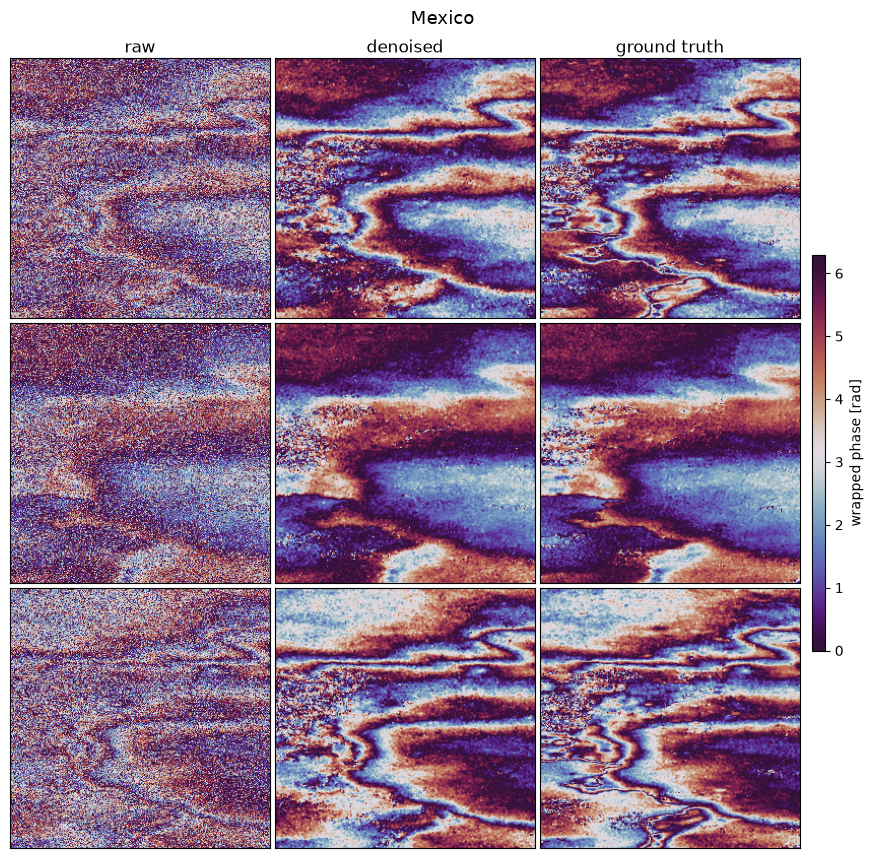

In [10]:

mexico_denoised = mexico_insarflow.denoise(mexico_raw.to(DEVICE), steps=N_STEPS, method="midpoint", use_ema=True)
show(mexico_raw, mexico_denoised, mexico_clean, "Mexico", img_size=IMG_SIZE)

## Simulation — synthetic InSAR dataset

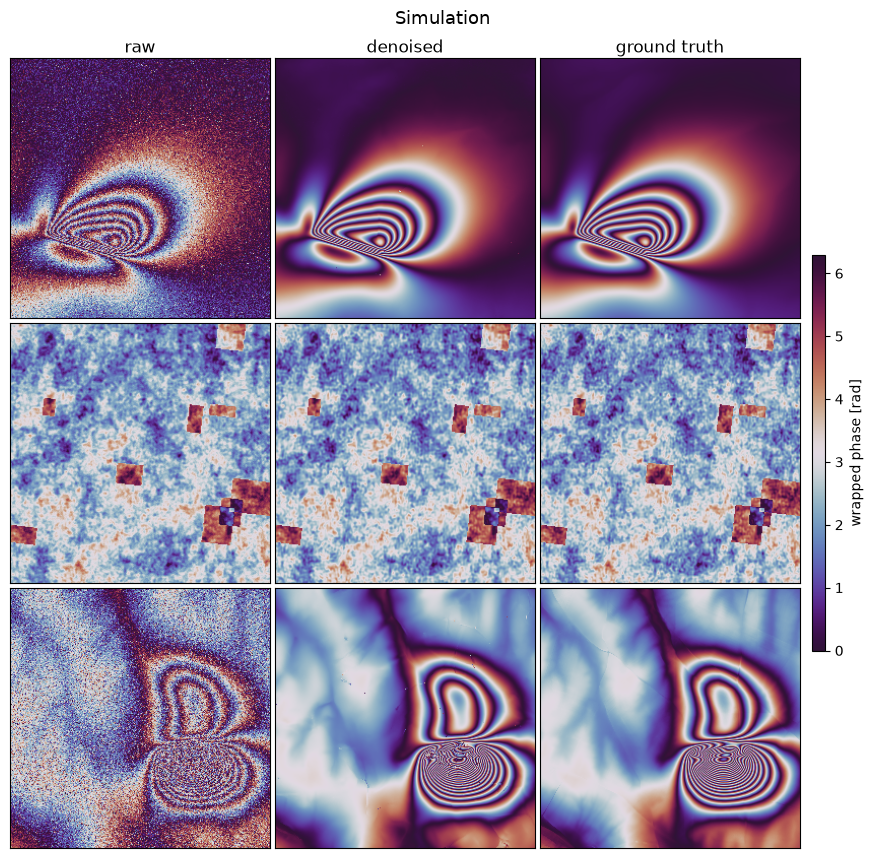

In [11]:
simulation_denoised = simulation_insarflow.denoise(simulation_raw.to(DEVICE), steps=N_STEPS, method="midpoint", use_ema=True)
show(simulation_raw, simulation_denoised, simulation_clean, "Simulation", img_size=IMG_SIZE)